<a href="https://colab.research.google.com/github/Misha-private/Demo-repo/blob/main/Analytical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 30.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
from pysr import PySRRegressor

# 1. Prepare your specific data
y_values = np.array([
    0.000400, 0.000400, 0.000400, 0.001930, 0.001600, 0.001370, 0.001230,
    0.001120, 0.001040, 0.000970, 0.000920, 0.000870, 0.000830, 0.000790,
    0.000760, 0.000730, 0.000710, 0.000690, 0.000660, 0.000650, 0.000630,
    0.000600, 0.000600, 0.000500, 0.000500, 0.000500, 0.000500, 0.000500,
    0.000500, 0.000500, 0.000500, 0.000500, 0.000400, 0.000400, 0.000400,
    0.000400, 0.000400, 0.000400, 0.000400, 0.000400, 0.000400
])

# Create x as 1.0, 1.1, 1.2... matching the length of y
x_values = np.linspace(1.0, 1.0 + (len(y_values)-1)*0.1, len(y_values))

# We want x = f(y), so y is the input 'X' for the model
X = y_values.reshape(-1, 1)
y = x_values

# 2. Run the Regressor
model = PySRRegressor(
    niterations=100,
    binary_operators=["+", "*", "-", "/"],
    unary_operators=["log", "exp", "inv(x) = 1/x"], # Added inverse for decay
    model_selection="best",
    extra_sympy_mappings={'inv': lambda x: 1/x}
)

model.fit(X, y)

print(f"\nBest Analytical Function for x = f(y):")
print(model.sympy())

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 6.930e+04
Progress: 234 / 3100 total iterations (7.548%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.400e+00  0.000e+00  y = 3
3           8.264e-01  2.636e-01  y = 0.0016648 / x₀
5           8.152e-01  6.803e-03  y = (x₀ * -2077.1) - -4.4983
6           7.432e-01  9.246e-02  y = (log(x₀) * -1.9378) + -11.313
10          7.432e-01  3.129e-06  y = inv(inv(-11.313 + (log(x₀) * -1.9378))) + x₀
15          7.431e-01  3.271e-05  y = (log(x₀ + x₀) / inv(log(x₀) / (log(x₀) / -1.9149))) - ...
                                      9.8221
17          7.431e-01  7.421e-06  y = ((log(x₀) / inv(log(x₀) / (log(x₀) / -1.915))) + (-0.3...
                                      2797 - 10.823)) + x₀
18          7.429e-01  3.185e-04  y = (log(x₀) / inv((log(x₀)

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.400e+00  0.000e+00  y = 3
3           8.264e-01  2.636e-01  y = 0.0016648 / x₀
4           8.264e-01  5.960e-08  y = inv(x₀ / 0.0016648)
5           7.624e-01  8.054e-02  y = (0.0012823 / x₀) + 0.75442
6           7.431e-01  2.570e-02  y = -11.149 - (log(x₀) * 1.9148)
7           7.329e-01  1.377e-02  y = ((-3.503e-07 / x₀) + 0.0024096) / x₀
9           7.276e-01  3.646e-03  y = (((-5.4789e-07 / x₀) + 0.0031142) / x₀) + -0.56146
11          7.276e-01  1.189e-05  y = (x₀ + -0.56146) + (((-5.4789e-07 / x₀) + 0.0031142) / ...
                                      x₀)
13          7.275e-01  9.055e-05  y = ((((-5.4789e-07 / x₀) + 0.0031144) / x₀) + (x₀ / 0.067...
                                      483)) + -0.56248
14          7.269e-01  7.218e-04  y = (((-1.7392e-06 / (x₀ / 0.33393)) + 0.0032961) / x₀) - ...
                         

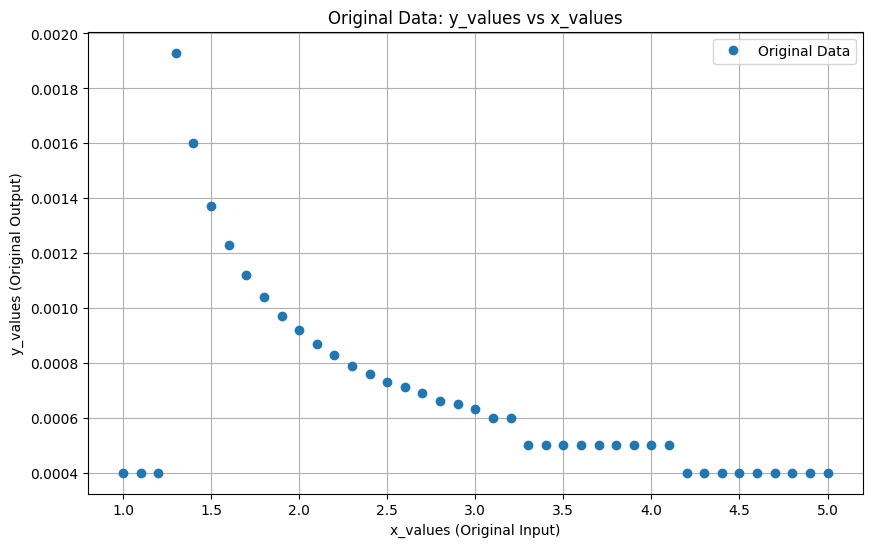

In [ ]:
import matplotlib.pyplot as plt

# Plotting the original data (y_values vs x_values)
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'o', label='Original Data')
plt.title('Original Data: y_values vs x_values')
plt.xlabel('x_values (Original Input)')
plt.ylabel('y_values (Original Output)')
plt.grid(True)
plt.legend()
plt.show()

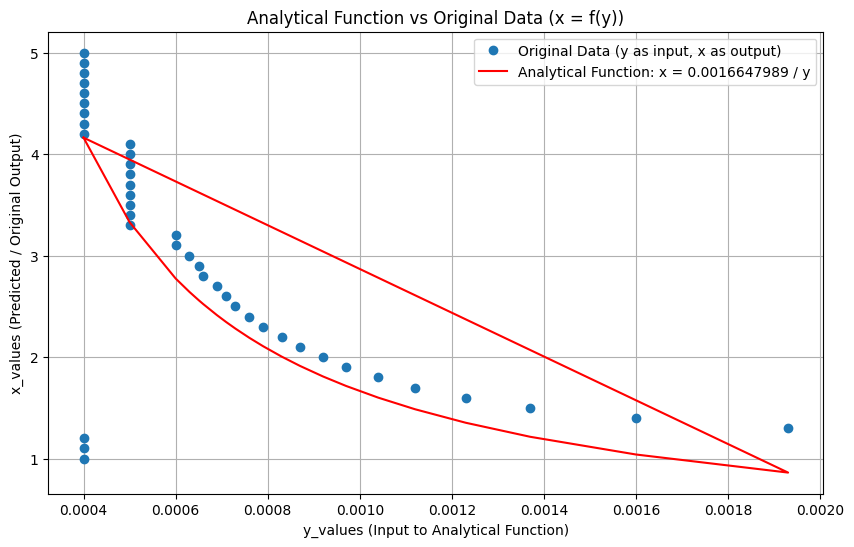

In [ ]:
# Calculate x values based on the analytical function: x = 0.0016647989 / y
predicted_x_values = 0.0016647989 / y_values

# Plotting the analytical function against the original x_values
plt.figure(figsize=(10, 6))
plt.plot(y_values, x_values, 'o', label='Original Data (y as input, x as output)')
plt.plot(y_values, predicted_x_values, '-', label='Analytical Function: x = 0.0016647989 / y', color='red')
plt.title('Analytical Function vs Original Data (x = f(y))')
plt.xlabel('y_values (Input to Analytical Function)')
plt.ylabel('x_values (Predicted / Original Output)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import numpy as np
from pysr import PySRRegressor

# 1. Prepare your specific data
y_values = np.array([3.4957,
  3.5732,
   3.6487,
   3.7240,
   3.7986,
   3.8724,
   3.9451,
   4.0208,
   4.1056,
   4.1858,
   4.2613,
  4.3310,
   4.3978,
   4.4628,
   4.5258,
   4.5909,
   4.6535,
   4.7147,
   4.7753,
   4.8358,
   4.8952,
   4.9519,
   5.0108,
   5.0771,
   5.1387,
   5.1979,
   5.2592,
   5.3148,
   5.3725,
   5.4264,
   5.4812,
   5.5346,
   5.5876,
   5.6371,
   5.6909,
   5.7940,
   5.8431,
   5.8892,
   5.9383,
   5.9837,
   6.0398,
   6.0903,
   6.1396,
   6.1903,
   6.2398,
   6.2908,
   6.3357,
   6.3870,
   6.4290,
   6.4753,
   6.5283,
   6.5717,
   6.6165,
   6.6573,
   6.7016,
   6.7475,
   6.7847,
   6.8300,
   6.8677,
   6.9163,
   6.9540,
   6.9925,
   7.0322,
   7.0780,
  7.1306,
   7.1739,
   7.2182,
   7.2505,
   7.2973,
   7.3367,
   7.3806,
   7.4257,
   7.4606,
   7.4974,
   7.5456,
   7.5775,
   7.6232,
   7.6521,
   7.6909,

])

# Create x as 1.0, 1.1, 1.2... matching the length of y
x_values = np.linspace(1.0, 1.0 + (len(y_values)-1)*0.1, len(y_values))

# We want x = f(y), so y is the input 'X' for the model
X = y_values.reshape(-1, 1)
y = x_values

# 2. Run the Regressor
model = PySRRegressor(
    niterations=100,
    binary_operators=["+", "*", "-", "/"],
    unary_operators=["log", "exp", "inv(x) = 1/x"], # Added inverse for decay
    model_selection="best",
    extra_sympy_mappings={'inv': lambda x: 1/x}
)

model.fit(X, y)

print(f"\nBest Analytical Function for x = f(y):")
print(model.sympy())

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 8.530e+04
Progress: 487 / 3100 total iterations (15.710%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.200e+00  0.000e+00  y = 4.9
3           1.170e+00  7.460e-01  y = x₀ + -0.94936
4           5.206e-01  8.094e-01  y = exp(x₀ * 0.2731)
5           4.972e-02  2.349e+00  y = -6.0602 - (x₀ * -1.8737)
6           2.536e-02  6.731e-01  y = x₀ * log(x₀ * 0.38804)
7           6.531e-04  3.659e+00  y = -0.97596 - ((x₀ * -0.16468) * x₀)
9           6.483e-04  3.718e-03  y = -0.92423 - ((0.018848 - (x₀ * 0.16632)) * x₀)
11          6.483e-04  1.341e-06  y = (x₀ * -0.018808) - (0.92434 - ((x₀ * 0.16631) * x₀))
13          6.159e-04  2.559e-02  y = -0.81298 - (inv(exp(x₀)) + ((0.051639 - (x₀ * 0.16874)...
                                      ) * x₀))


[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 9.830e+04
Progress: 2975 / 3100 total iterations (95.968%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.071e+00  0.000e+00  y = x₀
3           1.170e+00  2.857e-01  y = x₀ + -0.94936
4           5.206e-01  8.094e-01  y = exp(x₀ * 0.27317)
5           4.972e-02  2.349e+00  y = -6.0602 - (x₀ * -1.8737)
6           2.403e-02  7.272e-01  y = exp(x₀ * 0.30756) + -1.5568
7           6.531e-04  3.605e+00  y = -0.97593 - (x₀ * (x₀ * -0.16468))
9           6.483e-04  3.720e-03  y = ((-0.018827 - (x₀ * -0.16631)) * x₀) - 0.92429
11          4.039e-04  2.366e-01  y = (((x₀ * x₀) * 0.011643) - -1.0656) * (x₀ - 2.672)
13          4.024e-04  1.860e-03  y = (x₀ * (((x₀ * (x₀ + -1.5445)) * 0.010795) - -0.98592))...
                                       - 2.

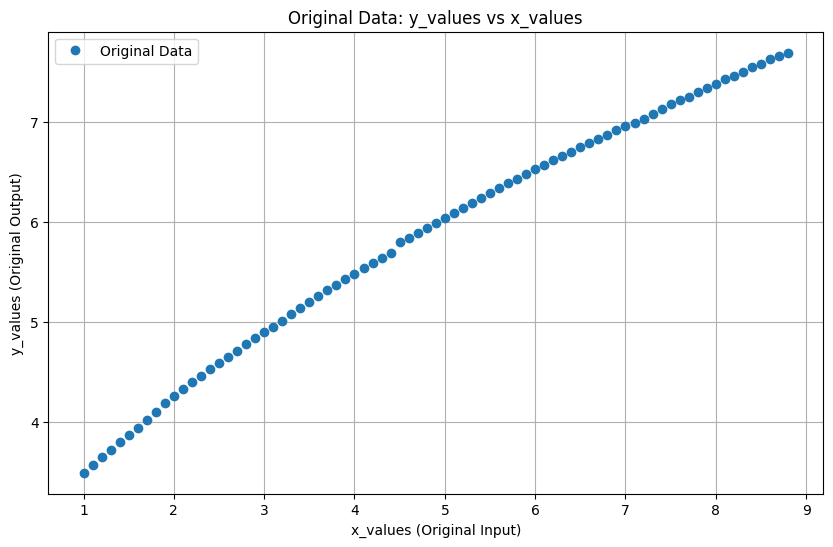

In [ ]:
import matplotlib.pyplot as plt

# Plotting the original data (y_values vs x_values)
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'o', label='Original Data')
plt.title('Original Data: y_values vs x_values')
plt.xlabel('x_values (Original Input)')
plt.ylabel('y_values (Original Output)')
plt.grid(True)
plt.legend()
plt.show()

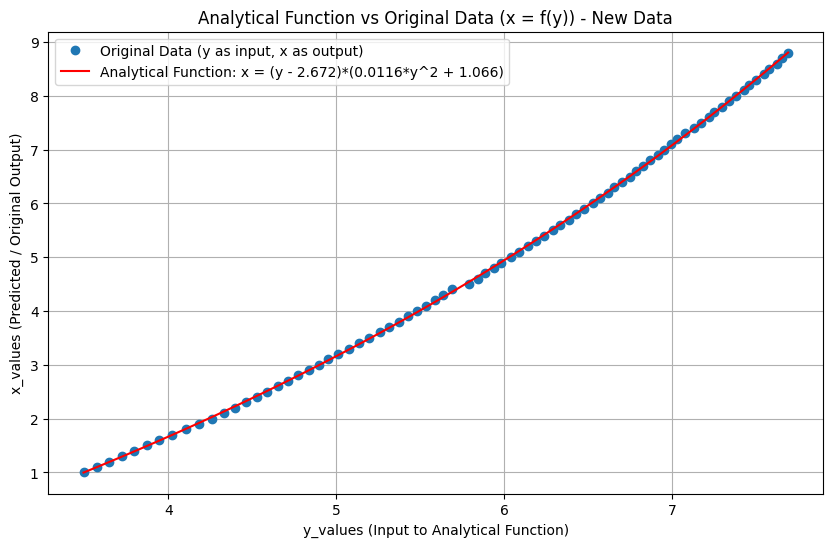

In [ ]:
# Calculate x values based on the analytical function: x = (y - 2.6720054) * (0.011642612 * y**2 + 1.0655638)
predicted_x_values_new = (y_values - 2.6720054) * (0.011642612 * y_values**2 + 1.0655638)

# Plotting the analytical function against the original x_values
plt.figure(figsize=(10, 6))
plt.plot(y_values, x_values, 'o', label='Original Data (y as input, x as output)')
plt.plot(y_values, predicted_x_values_new, '-', label='Analytical Function: x = (y - 2.672)*(0.0116*y^2 + 1.066)', color='red')
plt.title('Analytical Function vs Original Data (x = f(y)) - New Data')
plt.xlabel('y_values (Input to Analytical Function)')
plt.ylabel('x_values (Predicted / Original Output)')
plt.grid(True)
plt.legend()
plt.show()

# Aspect tensor and correlation length for radial beta fileter

In [ ]:
import numpy as np
from pysr import PySRRegressor

# 1. Prepare your specific data
y_values = np.array([
  17.691364,
18.467929,
19.155036,
19.817682,
20.542589,
21.283295,
22.001159,
22.700964,
23.384593,
24.038277,
24.655469,
25.237350,
25.802949,
26.369654,
26.929688,
27.476996,
28.012787,
28.558467,
29.090892,
29.617257,
30.122600,
30.612496,
31.078814,
31.550786,
32.020152,
32.491955,
32.952446,
33.417369,
33.869802,
34.323991,
34.766214,
35.197307,
35.621246,
36.034940,
36.444270,
36.843364,
37.245458,
37.641891,
38.031296,
38.429898,
38.816586,
39.205990,
39.595419,
39.977475,
40.355728,
40.734898,
41.113246,
41.483233,
41.843177,
42.208160,
42.561500,
42.908137,
43.256473,
43.594744,
43.929029,
44.261859,
44.602014,
44.923444,
45.265159,
45.595997,
45.929483,
46.261233,
46.591029,
46.917466,
47.241422,
47.563774,
47.881587,
48.198038,
48.507462,
48.820740,
49.126815,
49.424154,
49.723576,
50.024093,
50.326095,
50.622257,
50.917103,
51.213048,
51.505624,
51.788545,
52.084122,
52.377889,
52.658997,
52.944727,
53.220286,
53.519663,
53.788498,
54.079626,
54.364499,
54.642217,
])

# Create x as 1.0, 1.1, 1.2... matching the length of y
x_values = np.linspace(1.0, 1.0 + (len(y_values)-1)*0.1, len(y_values))

# We want x = f(y), so y is the input 'X' for the model
X = y_values.reshape(-1, 1)
y = x_values

# 2. Run the Regressor
model = PySRRegressor(
    niterations=100,
    binary_operators=["+", "*", "-", "/"],
    unary_operators=["log", "exp", "inv(x) = 1/x"], # Added inverse for decay
    model_selection="best",
    extra_sympy_mappings={'inv': lambda x: 1/x}
)

model.fit(X, y)

print(f"\nBest Analytical Function for x = f(y):")
print(model.sympy())

[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] WARNING: You have Julia 1.12.6 installed but 1.10.3 - 1.11 is required.
[juliapkg]   It is recommended that you upgrade Julia or install JuliaUp.
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.9 to /root/.julia/environments/pyjuliapkg/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 7.640e+04
Progress: 430 / 3100 total iterations (13.871%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.749e+00  0.000e+00  y = 5.45
3           1.313e+00  8.184e-01  y = x₀ * 0.14618
5           5.720e-05  5.021e+00  y = x₀ * (x₀ * 0.0033158)
7           3.453e-05  2.524e-01  y = (x₀ * 0.0033294) * (x₀ + -0.18673)
9           3.003e-05  6.985e-02  y = ((0.0033218 / inv(x₀)) / inv(x₀)) + -0.012135
10          2.997e-05  2.020e-03  y = (((x₀ * x₀) - inv(x₀)) * 0.0033218) + -0.011988
11          2.826e-05  5.876e-02  y = (((x₀ + 0.11062) * (x₀ * -0.0017657)) + 0.0096978) / -...
                                      0.53234
13          2.822e-05  7.016e-04  y = (((((x₀ + 0.11115) * x₀) * -0.002941) + 0.16801) / -0....
                            

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.749e+00  0.000e+00  y = 5.45
3           1.313e+00  8.184e-01  y = x₀ * 0.14618
4           1.879e-01  1.945e+00  y = exp(x₀ * 0.041901)
5           5.720e-05  8.097e+00  y = (x₀ * 0.0033158) * x₀
7           3.003e-05  3.222e-01  y = (x₀ * (x₀ * 0.0033218)) + -0.012131
9           2.556e-05  8.047e-02  y = (((x₀ * 0.0033012) + 0.0015665) * x₀) + -0.039647
11          1.833e-05  1.663e-01  y = (((-0.74278 / (x₀ + -16.578)) + x₀) * 0.003318) * x₀
13          1.782e-05  1.412e-02  y = ((x₀ + (-0.66017 / (x₀ + -16.603))) + -0.037643) * (x₀...
                                       * 0.0033205)
14          1.657e-05  7.255e-02  y = (((x₀ * 0.0033204) * x₀) + -0.0089814) - (0.00027623 /...
                                       exp(x₀ + -22.467))
16          1.651e-05  1.941e-03  y = ((-7.4787e-06 / exp(x₀ + -26.033)) + (x₀ * ((x₀ + 0.0

# Ploting radial function (original data)

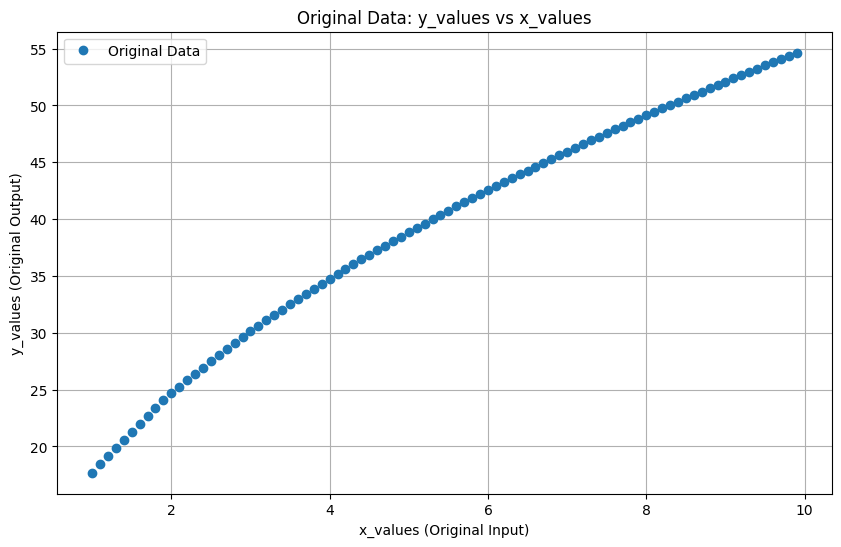

In [ ]:
import matplotlib.pyplot as plt

# Plotting the original data (y_values vs x_values)
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'o', label='Original Data')
plt.title('Original Data: y_values vs x_values')
plt.xlabel('x_values (Original Input)')
plt.ylabel('y_values (Original Output)')
plt.grid(True)
plt.legend()

# Plotting inverse function

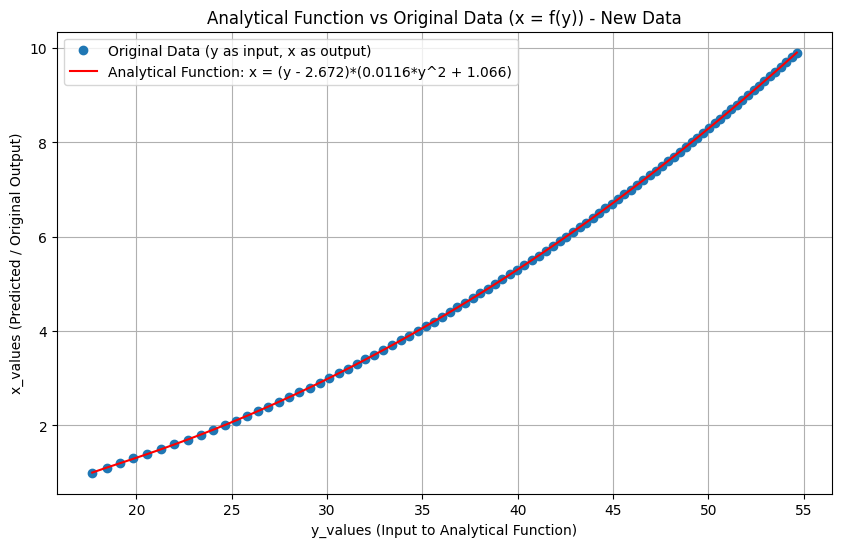

In [ ]:
# Calculate x values based on the analytical function: x = (y - 2.6720054) * (0.011642612 * y**2 + 1.0655638)
predicted_x_values_new = (y_values - 0.7428/(y_values - 16.578))*0.003318* y_values
# Plotting the analytical function against the original x_values
plt.figure(figsize=(10, 6))
plt.plot(y_values, x_values, 'o', label='Original Data (y as input, x as output)')
plt.plot(y_values, predicted_x_values_new, '-', label='Analytical Function: x = (y - 2.672)*(0.0116*y^2 + 1.066)', color='red')
plt.title('Analytical Function vs Original Data (x = f(y)) - New Data')
plt.xlabel('y_values (Input to Analytical Function)')
plt.ylabel('x_values (Predicted / Original Output)')
plt.grid(True)
plt.legend()
plt.show()

# Find connection for 2-pass line fileter

In [ ]:
import numpy as np
from pysr import PySRRegressor

# 1. Prepare your specific data
y_values = np.array([
17.382858,
18.235314,
18.934565,
19.510860,
20.107412,
20.784642,
21.497565,
22.212568,
22.914463,
23.594839,
24.231686,
24.826333,
25.377627,
25.883536,
26.391653,
26.912298,
27.438745,
27.960324,
28.492793,
29.011725,
29.530936,
30.030540,
30.525991,
30.998608,
31.458826,
31.899275,
32.323831,
32.747765,
33.178557,
33.614024,
34.049626,
34.480549,
34.906405,
35.329102,
35.743104,
36.153877,
36.555650,
36.952867,
37.342843,
37.723642,
38.096383,
38.463412,
38.816407,
39.182539,
39.546662,
39.910687,
40.276183,
40.638512,
41.003889,
41.364311,
41.724424,
42.079078,
42.426258,
42.776233,
43.115491,
43.447132,
43.777262,
44.104082,
44.420556,
44.738853,
45.051833,
45.354793,
45.664349,
45.976650,
46.291108,
46.609510,
46.913640,
47.226905,
47.546078,
47.852065,
48.159569,
48.474944,
48.772010,
49.072217,
49.371639,
49.675725,
49.962193,
50.255979,
50.539117,
50.813311,
51.092047,
51.364641,
51.648222,
51.917756,
52.190346,
52.454667,
52.733709,
53.006290,
53.281980,
53.559931
])

# Create x as 1.0, 1.1, 1.2... matching the length of y
x_values = np.linspace(1.0, 1.0 + (len(y_values)-1)*0.5, len(y_values))

# We want x = f(y), so y is the input 'X' for the model
X = y_values.reshape(-1, 1)
y = x_values

# 2. Run the Regressor
model = PySRRegressor(
    niterations=100,
    binary_operators=["+", "*", "-", "/"],
    unary_operators=["log", "exp", "inv(x) = 1/x"], # Added inverse for decay
    model_selection="best",
    extra_sympy_mappings={'inv': lambda x: 1/x}
)

model.fit(X, y)

print(f"\nBest Analytical Function for x = f(y):")
print(model.sympy())

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 5.440e+04
Progress: 285 / 3100 total iterations (9.194%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.687e+02  0.000e+00  y = 23.25
3           1.014e+01  1.406e+00  y = x₀ + -15.194
5           2.776e+00  6.479e-01  y = -25.457 - (x₀ * -1.2669)
7           2.277e-03  3.553e+00  y = (x₀ * (x₀ * 0.017277)) + -4.0711
9           2.277e-03  2.921e-06  y = ((x₀ * (x₀ * 0.043347)) / 2.5089) + -4.0714
12          2.187e-03  1.355e-02  y = (((x₀ * x₀) * 0.017268) + -4.0339) - (inv(x₀) / 1.2429...
                                      )
13          2.098e-03  4.133e-02  y = ((x₀ * (x₀ - (x₀ * 0.98286))) - 4.2417) - (x₀ * -0.009...
                                      8998)
15          2.098e-03  9.788e-05  y = ((x₀ - (x₀ * 0.98286)) * x₀) - (4.2424 

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.687e+02  0.000e+00  y = 23.251
3           1.014e+01  1.406e+00  y = x₀ + -15.194
5           2.776e+00  6.479e-01  y = -25.457 - (x₀ * -1.2669)
7           2.277e-03  3.553e+00  y = (235.64 - (x₀ * x₀)) * -0.017277
9           2.098e-03  4.091e-02  y = (x₀ * ((x₀ * 0.01714) - -0.010189)) + -4.2468
11          2.080e-03  4.487e-03  y = (-3.7432 - inv(log(x₀))) + ((x₀ * x₀) * 0.017246)
12          1.758e-03  1.679e-01  y = ((x₀ * (inv(x₀ + -15.953) - x₀)) + 231.98) * -0.017258
13          1.682e-03  4.416e-02  y = ((inv(exp(x₀) / -23546) + 0.017267) * (x₀ * x₀)) + -4....
                                      0505
15          1.635e-03  1.439e-02  y = ((inv((exp(x₀) / -38622) + -654.69) + 0.017265) * (x₀ ...
                                      * x₀)) + -4.0469
17          1.630e-03  1.474e-03  y = ((0.017265 + inv((exp(x₀ + -0.1136

# Vertical correlation lengths

In [ ]:
import numpy as np
from pysr import PySRRegressor

# 1. Prepare your specific data
y_values = np.array([
  1.544,
  1.856,
  2.139,
  2.395,
  2.623,
  2.818,
  3.021,
  3.210,
  3.376,
  3.527,
  3.712,
  3.841,
  3.992,
  4.125,
  4.257,
  4.398,
  4.527,
  4.648,
  4.765,
  4.880,
  4.995,
  5.111,
  5.221,
  5.329,
  5.434,
  5.535,
  5.633,
  5.733,
  5.834,
  5.932,
  6.028,
  6.120,
  6.211,
  6.298,
  6.385,
  6.476,
  6.566,
  6.654,
])

# Create x as 1.0, 1.1, 1.2... matching the length of y
x_values = np.linspace(1.0, 1.0 + (len(y_values)-1)*0.1, len(y_values))

# We want x = f(y), so y is the input 'X' for the model
X = y_values.reshape(-1, 1)
y = x_values

# 2. Run the Regressor
model = PySRRegressor(
    niterations=100,
    binary_operators=["+", "*", "-", "/"],
    unary_operators=["log", "exp", "inv(x) = 1/x"], # Added inverse for decay
    model_selection="best",
    extra_sympy_mappings={'inv': lambda x: 1/x}
)

model.fit(X, y)

print(f"\nBest Analytical Function for x = f(y):")
print(model.sympy())


/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 7.800e+04
Progress: 484 / 3100 total iterations (15.613%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.202e+00  0.000e+00  y = 2.85
3           6.703e-02  1.444e+00  y = x₀ * 0.63062
4           5.861e-02  1.341e-01  y = exp(x₀ * 0.22519)
5           3.034e-02  6.586e-01  y = (x₀ * 0.75888) + -0.64782
6           1.186e-02  9.394e-01  y = (x₀ - log(x₀)) + -0.29131
7           1.182e-05  6.911e+00  y = (x₀ * (x₀ * 0.088322)) + 0.79386
9           1.177e-05  1.943e-03  y = (x₀ * ((x₀ * 0.088221) + 0.00088605)) + 0.79213
11          1.177e-05  6.914e-06  y = ((x₀ * 0.00094473) + ((x₀ * x₀) * 0.088215)) + 0.792
12          1.172e-05  4.879e-03  y = (inv(x₀) * -0.0054448) + (((x₀ * 0.08828) * x₀) + 0.79...
                                      62)

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.202e+00  0.000e+00  y = 2.85
3           6.703e-02  1.444e+00  y = x₀ * 0.63062
4           5.861e-02  1.341e-01  y = exp(x₀ * 0.22521)
5           3.034e-02  6.586e-01  y = (x₀ * 0.75888) + -0.64783
6           4.398e-04  4.234e+00  y = exp(x₀ * 0.24921) - 0.49718
7           1.182e-05  3.617e+00  y = ((x₀ * 0.088322) * x₀) + 0.79387
9           1.177e-05  1.944e-03  y = (x₀ * ((x₀ * 0.088215) + 0.00094476)) + 0.792
11          1.172e-05  2.440e-03  y = ((x₀ * x₀) * 0.08828) + ((-0.0054477 / x₀) + 0.79619)
12          1.162e-05  8.568e-03  y = (((x₀ * 0.088283) * x₀) + 0.79625) - (0.0019347 / log(...
                                      x₀))
13          8.765e-06  2.816e-01  y = (((x₀ * x₀) + (-0.0048713 / (-3.668 + x₀))) * 0.088322...
                                      ) + 0.79418
15          8.759e-06  3.398e-04  y = ((0.088

# 2D function (amplitudes)

In [ ]:
## Place data ampl_90x38.txt on drive

In [ ]:
import numpy as np

# Replace with your actual path
file_path = '/content/drive/MyDrive/path_to_your_file/y_data.txt'

# Fast loading for large text files
y_data = np.genfromtxt(file_path)

# Verify the size (should be 90 * 38 = 3420)
print(f"Loaded array shape: {y_data.shape}")

In [ ]:
x_range = np.arange(1.0, 10.0, 0.1) # 90 values
z_range = np.arange(1.0, 20.0, 0.5) # 38 values

# 2. Reshape and Match
# Ensure your loaded array is exactly 3420 elements
y_data = y_data.reshape(90, 38)

# Create the coordinate pairs for PySR
zv, xv = np.meshgrid(z_range, x_range)
X_features = np.stack([xv.flatten(), zv.flatten()], axis=1)
y_target = y_data.flatten()

# Proceed to model.fit(X_features, y_target)

In [ ]:
import numpy as np
from pysr import PySRRegressor

# 1. Reconstruct the coordinates
x_range = np.arange(1.0, 10.0, 0.1) # 90 values
z_range = np.arange(1.0, 20.0, 0.5) # 38 values

# 2. Create the coordinate pairs (the Meshgrid)
# Assuming your 1D array was flattened 'C-style' (row by row)
zv, xv = np.meshgrid(z_range, x_range)
X_features = np.stack([xv.flatten(), zv.flatten()], axis=1)

# 3. Your 1D data array (replace this with your actual array)
# y_data = np.array([

])
y_data = y_data.flatten()

# 4. Initialize Regressor for 2 variables
model = PySRRegressor(
    niterations=100,
    binary_operators=["+", "*", "-", "/"],
    unary_operators=["exp", "log", "sqrt"],
    variable_names=["x", "z"],
)

model.fit(X_features, y_data)

print("Discovered 2D Analytical Function:")
print(model.sympy())

In [ ]:
from google.colab import drive
import os
def is_drive_mounted():
    return os.path.exists('/content/drive')
if not is_drive_mounted(): drive.mount('/content/drive')


Mounted at /content/drive


# Read amplitudes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Set the file path
file_path = '/content/drive/MyDrive/MGBF/ampl_90x38_rad.txt'

try:
    # 3. Load the 1D data
    # This reads the text file regardless of spaces or newlines
    raw_data = np.loadtxt(file_path)
    print(f"Data Loaded Successfully!")
    print(f"Total number of points: {len(raw_data)}")

    # 4. Define your coordinates
    # X (Horizontal): 0.1 to 9.0 (90 points)
    # Y (Vertical): 1.0 to 19.5 (38 points)
    # Total expected: 90 * 38 = 3420
    rows = 90
    cols = 38

    if len(raw_data) == rows * cols:
        # 5. Reshape to 2D
        # We assume Row-Major order (X is constant, Y cycles)
        grid = raw_data.reshape((rows, cols))

        # 6. Plotting
        plt.figure(figsize=(12, 6))

        # 'extent' maps the axes to your physical X and Y values
        # [left, right, bottom, top] -> [Y_min, Y_max, X_max, X_min]
        # We use X_max to X_min for the Y-axis of the plot so it reads top-to-bottom
        im = plt.imshow(grid, extent=[1.0, 19.5, 9.0, 0.1], aspect='auto', cmap='magma')

        plt.colorbar(im, label='Amplitude')
        plt.xlabel('Vertical Intensity (Y)')
        plt.ylabel('Horizontal Intensity (X)')
        plt.title('Heatmap of Beta Filter Amplitude Response')
        plt.grid(False)
        plt.show()

        print("Verification: If the plot shows a smooth surface, the reshaping is correct.")
    else:
        print(f"Dimension Mismatch: File has {len(raw_data)} points, but we expected {rows*cols}.")

except Exception as e:
    print(f"An error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
An error occurred: could not convert string '0.018780,' to float64 at row 0, column 1.


Mounted at /content/drive
Data Loaded Successfully!
Total number of points found: 3420


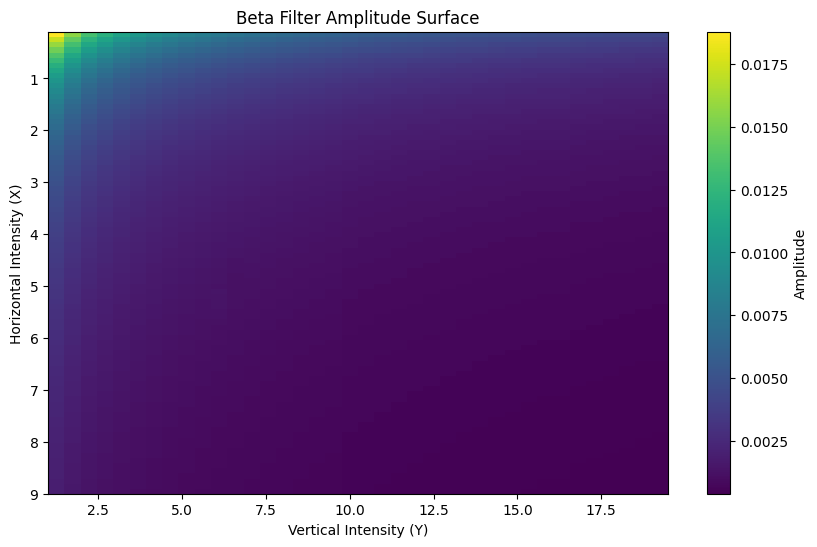

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Handle Drive (using force_remount=True to clear the warning if needed)
drive.mount("/content/drive", force_remount=True)

file_path = '/content/drive/MyDrive/MGBF/ampl_90x38.txt'

try:
    # 2. Load the data, explicitly telling it to handle commas
    # 'deletechars' removes commas if they are attached to the numbers
    raw_data = np.genfromtxt(file_path, delimiter=',', invalid_raise=False)

    # If the file has trailing commas, genfromtxt might add a column of NaNs.
    # This line removes any NaN values to keep only the numbers.
    raw_data = raw_data[~np.isnan(raw_data)]

    print(f"Data Loaded Successfully!")
    print(f"Total number of points found: {len(raw_data)}")

    # 3. Define the 90x38 grid
    rows = 90
    cols = 38

    if len(raw_data) >= rows * cols:
        # Trim if there's extra data, or just take the first 3420 points
        grid_data = raw_data[:rows*cols].reshape((rows, cols))

        # 4. Plotting
        plt.figure(figsize=(10, 6))

        # Extent: [Y_min, Y_max, X_max, X_min]
        # X is 0.1 to 9.0, Y is 1.0 to 19.5
        im = plt.imshow(grid_data, extent=[1.0, 19.5, 9.0, 0.1],
                        aspect='auto', cmap='viridis')

        plt.colorbar(im, label='Amplitude')
        plt.xlabel('Vertical Intensity (Y)')
        plt.ylabel('Horizontal Intensity (X)')
        plt.title('Beta Filter Amplitude Surface')
        plt.show()

    else:
        print(f"Error: Expected {rows*cols} points, but only found {len(raw_data)}.")

except Exception as e:
    print(f"New Error: {e}")

In [ ]:
import numpy as np
from pysr import PySRRegressor
from google.colab import drive

# 1. Setup
FILE_NAME = 'ampl_90x38.txt'
FOLDER_PATH = '/content/drive/MyDrive/MGBF/'
drive.mount('/content/drive', force_remount=True)

try:
    # 2. Load the Amplitude Data (the "Height" of your surface)
    a_data = np.loadtxt(FOLDER_PATH + FILE_NAME)

    # 3. Define the Input Grid
    # X (Horizontal Intensity): 0.1 to 9.0 (90 steps)
    # Z (Vertical Intensity): 1.0 to 19.5 (38 steps)
    x_coords = np.linspace(0.1, 9.0, 90)
    z_coords = np.linspace(1.0, 19.5, 38)

    # Create the grid.
    # meshgrid creates the coordinate pairs for every point in your file.
    ZV, XV = np.meshgrid(z_coords, x_coords)

    # Features (Inputs): X and Z
    # Target (Output): a (Amplitude)
    X_input = np.stack([XV.flatten(), ZV.flatten()], axis=1)
    y_target = a_data.flatten()

    # 4. Symbolic Regression for a = F(x, z)
    model = PySRRegressor(
        niterations=500,             # High iterations for a precise surface
        binary_operators=["+", "*", "-", "/"],
        unary_operators=["exp", "sqrt", "log"],
        model_selection="best",
        # We increase the 'parsimony' to ensure the result is a clean formula
        parsimony=0.001
    )

    print(f"Finding analytical surface: a = F(x, z)...")

    # We pass the variable names here during fit
    model.fit(X_input, y_target, variable_names=["x", "z"])

    print("\n" + "="*40)
    print("DIRECT ANALYTICAL SURFACE FUNCTION")
    print("="*40)
    print(f"a = {model.sympy()}")

except Exception as e:
    print(f"Error: {e}")

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...


Mounted at /content/drive
Finding analytical surface: a = F(x, z)...


[ Info: Started!


Streaming output truncated to the last 5000 lines.
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.470e+04
Progress: 1460 / 15500 total iterations (9.419%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.159e-06  0.000e+00  y = 0.0018682
3           3.087e-06  1.158e-02  y = 0.0073915 / z
4           1.376e-06  8.080e-01  y = 0.003056 / sqrt(x)
5           8.058e-07  5.349e-01  y = 0.021737 / (x + z)
6           2.329e-07  1.241e+00  y = 0.008146 / sqrt(x * z)
7           2.329e-07  5.960e-08  y = 0.008146 / (sqrt(z) * sqrt(x))
8           4.607e-08  1.621e+00  y = 0.021737 / ((x + 1.2196) * sqrt(z))
9           8.587e-09  1.680e+00  y = 0.

[ Info: Final population:
[ Info: Results saved to:



DIRECT ANALYTICAL SURFACE FUNCTION
a = -4.822864e-5 + 0.0197522638553252/(sqrt(z)*(x + 0.92909956))
  - outputs/20260430_191918_RRDpWE/hall_of_fame.csv


# Plotting 3D function

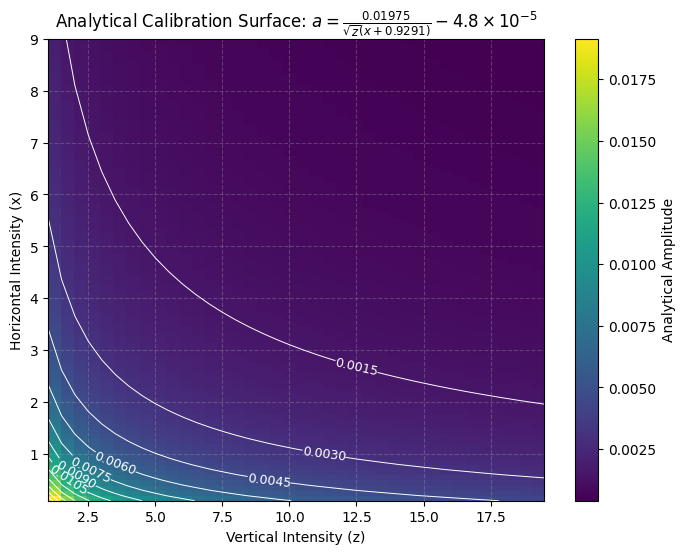

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Analytical Function from the PySR output
def f_amplitude(x, z):
    # a = -4.822864e-5 + 0.0197522638553252 / (sqrt(z) * (x + 0.92909956))
    offset = -4.822864e-5
    numerator = 0.0197522638553252
    denominator = np.sqrt(z) * (x + 0.92909956)
    return offset + (numerator / denominator)

# 2. Recreate the Grid Coordinates
# x: 0.1 to 9.0 (90 steps)
# z: 1.0 to 19.5 (38 steps)
x_coords = np.linspace(0.1, 9.0, 90)
z_coords = np.linspace(1.0, 19.5, 38)
Z_mesh, X_mesh = np.meshgrid(z_coords, x_coords)

# 3. Calculate Analytical Amplitudes
A_analytic = f_amplitude(X_mesh, Z_mesh)

# 4. Create the Plot
plt.figure(figsize=(8, 6))

# Heatmap (using the same extent and color map as before)
im = plt.imshow(A_analytic, origin='lower',
                extent=[z_coords.min(), z_coords.max(), x_coords.min(), x_coords.max()],
                aspect='auto', cmap='viridis')

# Contour Lines
contours = plt.contour(Z_mesh, X_mesh, A_analytic, levels=15, colors='white', linewidths=0.7)
plt.clabel(contours, inline=True, fontsize=9, fmt='%.4f')

# Labels and Styling
plt.colorbar(im, label='Analytical Amplitude')
plt.xlabel('Vertical Intensity (z)')
plt.ylabel('Horizontal Intensity (x)')
plt.title(r'Analytical Calibration Surface: $a = \frac{0.01975}{\sqrt{z}(x + 0.9291)} - 4.8\times10^{-5}$')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

# Plotting raw data

Mounted at /content/drive


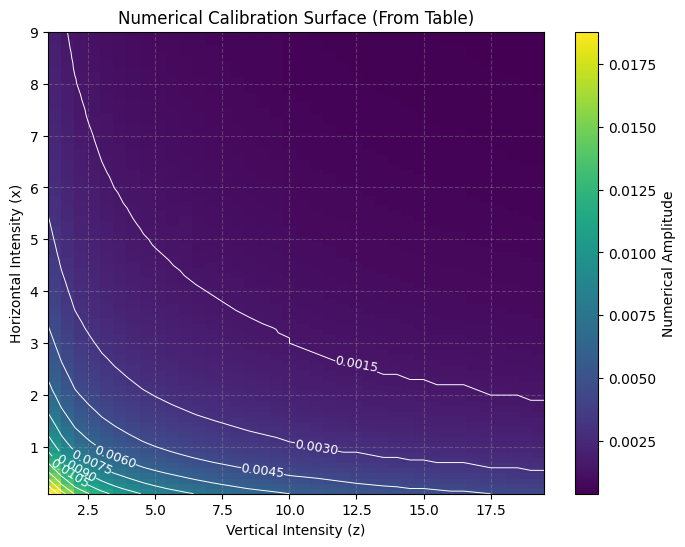

Plotting complete. Max Amplitude: 0.01878, Min: 0.00040


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Mount Drive and Load Data
drive.mount('/content/drive', force_remount=True)
file_path = '/content/drive/MyDrive/MGBF/ampl_90x38.txt' # Adjusted to your 90x38 dimensions

try:
    # Load the raw 1D array
    raw_data = np.loadtxt(file_path)

    # 2. Define the Dimensions and Coordinates
    rows, cols = 90, 38
    grid_data = raw_data.reshape((rows, cols))

    x_coords = np.linspace(0.1, 9.0, rows)  # Horizontal Intensity (x)
    z_coords = np.linspace(1.0, 19.5, cols) # Vertical Intensity (z)

    # Create meshgrid for the contour overlay
    Z_mesh, X_mesh = np.meshgrid(z_coords, x_coords)

    # 3. Create the Comparison Plot
    plt.figure(figsize=(8, 6))

    # Heatmap of the RAW data
    im = plt.imshow(grid_data, origin='lower',
                    extent=[z_coords.min(), z_coords.max(), x_coords.min(), x_coords.max()],
                    aspect='auto', cmap='viridis')

    # Contour Lines based on numerical values
    # We use 15 levels to match the analytical plot
    contours = plt.contour(Z_mesh, X_mesh, grid_data, levels=15, colors='white', linewidths=0.7)

    # Label the lines
    plt.clabel(contours, inline=True, fontsize=9, fmt='%.4f')

    # Labels and Formatting
    plt.colorbar(im, label='Numerical Amplitude')
    plt.xlabel('Vertical Intensity (z)')
    plt.ylabel('Horizontal Intensity (x)')
    plt.title('Numerical Calibration Surface (From Table)')
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.show()

    print(f"Plotting complete. Max Amplitude: {np.max(grid_data):.5f}, Min: {np.min(grid_data):.5f}")

except Exception as e:
    print(f"Error: {e}")